# Robert May and the Logistic Map

Robert May's 1976 paper made a sharp point: complicated long-term behaviour does not require a complicated model. A one-dimensional deterministic recurrence can pass from a stable equilibrium to oscillations, then to period-doubling cascades, and finally to chaos.

In this notebook we use the logistic map

$$
x_{n+1} = r x_n (1-x_n)
$$

as the main example. The goal is not just to state the result, but to reproduce the key phenomena computationally and connect them to the underlying analysis.

In [2]:
# Numerical tools for all experiments in the notebook.
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

## 1. Discrete Dynamical Systems

A discrete dynamical system updates a state by repeated application of a rule,

$$
x_{n+1} = f(x_n).
$$

A few basic terms are enough to read the rest of the notebook:

- **State**: the value $x_n$ at step $n$.
- **Iteration**: one application of the map $f$.
- **Orbit**: the sequence $x_0, x_1, x_2, \ldots$ generated from one initial value.
- **Fixed point**: a state $x^*$ such that $f(x^*) = x^*$.
- **Periodic orbit**: an orbit that repeats after some period $p$, so $x_{n+p} = x_n$.

The striking feature of nonlinear maps is that a very simple update rule can generate very different kinds of orbits as a parameter is varied.

## 2. The Logistic Map

May's discussion is centred on the recurrence

$$
x_{n+1} = r x_n (1-x_n), \qquad 0 \le x_n \le 1.
$$

Here:

- $x_n$ is the population at generation $n$, scaled by a carrying capacity so that it lies between $0$ and $1$.
- $r$ is a growth parameter.

The factor $x_n$ says that reproduction needs an existing population. The factor $(1-x_n)$ says that crowding suppresses growth. The map is therefore small when the population is near $0$ and also when it is near the carrying limit $1$.

A simple discrete population model makes this form natural:

$$
N_{n+1} = a N_n \left(1 - \frac{N_n}{K}\right).
$$

If we define $x_n = N_n/K$, then this becomes

$$
x_{n+1} = a x_n(1-x_n).
$$

So the logistic map is the dimensionless version of density-dependent population growth.

## 3. Fixed Points and Stability

To find fixed points we solve

$$
x = r x(1-x).
$$

Rearranging gives

$$
x\bigl[r(1-x)-1\bigr] = 0,
$$

so the fixed points are

$$
x_1^* = 0, \qquad x_2^* = 1 - \frac{1}{r}.
$$

A fixed point is stable if nearby states are pulled back toward it. For a one-dimensional map, the local condition is

$$
|f'(x^*)| < 1.
$$

For the logistic map,

$$
f'(x) = r(1-2x).
$$

At the origin,

$$
f'(0) = r,
$$

so $x^* = 0$ is stable for $0 < r < 1$.

At the nonzero fixed point,

$$
f'\left(1-\frac{1}{r}\right) = 2-r.
$$

Therefore the nonzero fixed point is stable when

$$
|2-r| < 1 \iff 1<r<3.
$$

So as $r$ increases, the long-term behaviour first shifts from extinction-like decay to a stable nonzero equilibrium.

## 4. The First Period-Doubling Bifurcation

The fixed point $x^* = 1 - 1/r$ loses stability when

$$
|2-r| = 1,
$$

which occurs at

$$
r = 3.
$$

At this threshold the slope has reached $-1$, so successive iterates start to overshoot in an alternating way. Beyond this point the orbit no longer settles to one value. Instead it settles to two alternating values, a period-2 orbit.

Those two values can be obtained from $f(f(x)) = x$ after removing the fixed-point solutions. The result is

$$
x_{\pm}^{(2)} = \frac{r+1 \pm \sqrt{(r-3)(r+1)}}{2r}.
$$

These are real only for $r \ge 3$, which is exactly where the first period doubling begins.

The stability of the period-2 orbit is determined by the derivative of the twice-iterated map:

$$
(f^2)'\bigl(x_{\pm}^{(2)}\bigr) = 4 + 2r - r^2.
$$

The next loss of stability occurs at

$$
r = 1 + \sqrt{6} \approx 3.44949,
$$

where a stable period-4 orbit is born. This is the start of the period-doubling cascade.

In [3]:
# Core reusable functions for simulation, visualization, and diagnostics.
def logistic_step(x, r):
    """Apply one step of the logistic map."""
    return r * x * (1.0 - x)


def simulate_logistic(r, x0, n_iter):
    """Return the orbit x_0, ..., x_n for the logistic map."""
    orbit = np.empty(n_iter + 1, dtype=float)
    orbit[0] = x0
    for n in range(n_iter):
        orbit[n + 1] = logistic_step(orbit[n], r)
    return orbit


def plot_cobweb(r, x0, n_steps, ax=None):
    """Draw a cobweb diagram for the logistic map."""
    if ax is None:
        ax = plt.gca()

    x = np.linspace(0.0, 1.0, 600)
    y = logistic_step(x, r)

    ax.plot(x, y, color="tab:blue", label=r"$f(x)=rx(1-x)$")
    ax.plot(x, x, color="black", linestyle="--", label=r"$y=x$")

    current = x0
    for _ in range(n_steps):
        next_value = logistic_step(current, r)
        ax.plot([current, current], [current, next_value], color="tab:red", lw=1.0)
        ax.plot([current, next_value], [next_value, next_value], color="tab:red", lw=1.0)
        current = next_value

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"$x_n$")
    ax.set_ylabel(r"$x_{n+1}$")
    ax.set_title(fr"Cobweb diagram, $r={r}$")
    return ax


def bifurcation_data(r_values, x0=0.2, n_transient=500, n_keep=200):
    """Collect asymptotic points for a bifurcation diagram."""
    rs = []
    xs = []
    for r in r_values:
        orbit = simulate_logistic(r, x0, n_transient + n_keep)
        tail = orbit[-n_keep:]
        rs.append(np.full(n_keep, r))
        xs.append(tail)
    return np.concatenate(rs), np.concatenate(xs)


def lyapunov_exponent(r, x0=0.2, n_transient=500, n_iter=1500):
    """Estimate the Lyapunov exponent for one parameter value."""
    x = x0
    for _ in range(n_transient):
        x = logistic_step(x, r)

    total = 0.0
    epsilon = 1e-12
    for _ in range(n_iter):
        total += np.log(abs(r * (1.0 - 2.0 * x)) + epsilon)
        x = logistic_step(x, r)
    return total / n_iter


def estimate_tail_period(r, x0=0.2, n_transient=1200, n_keep=256, decimals=8, max_period=64):
    """Estimate a small period from the tail of the orbit, if one is visible numerically."""
    orbit = simulate_logistic(r, x0, n_transient + n_keep)
    tail = np.round(orbit[-n_keep:], decimals=decimals)

    for period in [1, 2, 4, 8, 16, 32, 64]:
        if period > max_period or 2 * period > n_keep:
            continue
        reference = tail[-period:]
        comparison = tail[-2 * period:-period]
        if np.array_equal(reference, comparison):
            return period
    return np.nan

## 5. A First Geometric Picture of Iteration

Before looking at long parameter sweeps, it helps to see how iteration works geometrically. A cobweb diagram alternates between the curve $y=f(x)$ and the diagonal $y=x$. Each vertical move applies the map, and each horizontal move resets the value so the next iteration can begin.

This turns the abstract recurrence into a visible staircase.

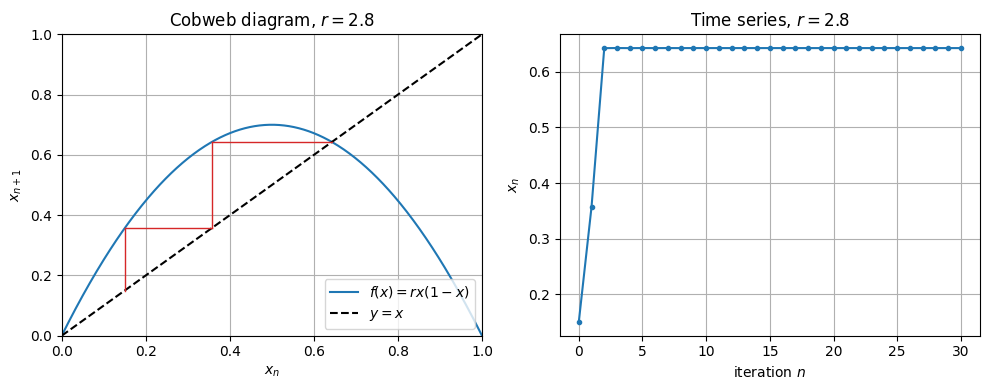

In [4]:
# A simple example: approach to a stable fixed point through repeated iteration.
r = 2.8
x0 = 0.15
orbit = simulate_logistic(r, x0, 30)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cobweb(r, x0, 20, ax=axes[0])
axes[0].legend(loc="lower right", frameon=True)

axes[1].plot(np.arange(len(orbit)), orbit, marker="o", ms=3)
axes[1].set_xlabel("iteration $n$")
axes[1].set_ylabel(r"$x_n$")
axes[1].set_title(fr"Time series, $r={r}$")

plt.tight_layout()
plt.show()

## 6. Iteration Simulation

May's point becomes concrete once we simulate the same recurrence for several values of $r$. The rule is unchanged; only the parameter moves.

We will compare four representative cases:

- $r=2.5$: convergence to a stable fixed point
- $r=3.2$: stable period-2 oscillation
- $r=3.5$: more complicated structured oscillation after several bifurcations
- $r=3.9$: chaotic behaviour

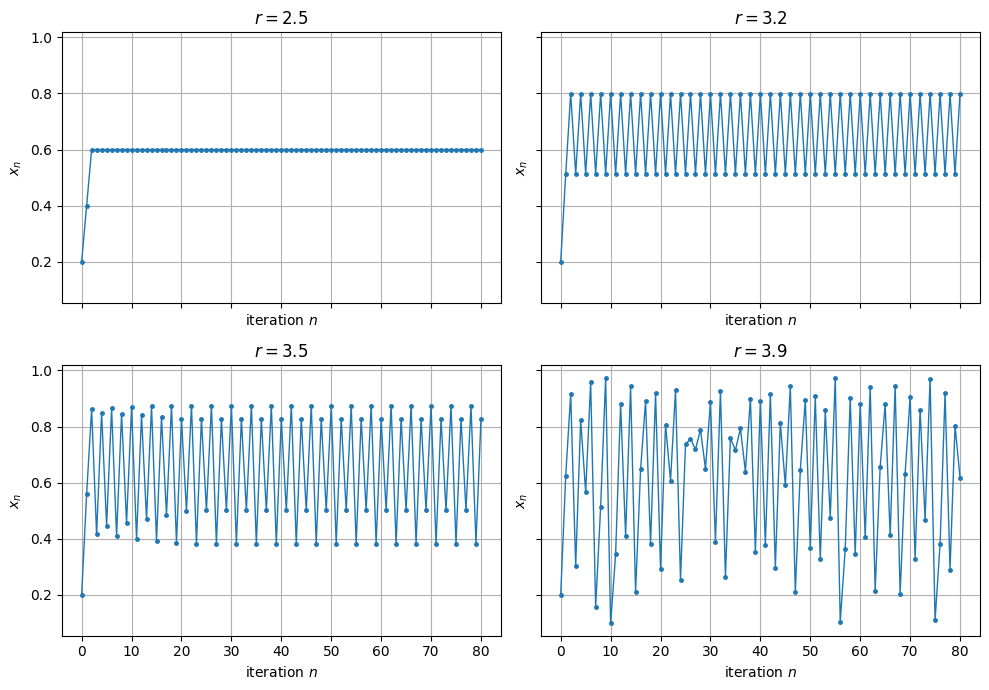

In [5]:
# Time series for four characteristic parameter values.
r_values = [2.5, 3.2, 3.5, 3.9]
x0 = 0.2
n_iter = 80

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, r in zip(axes.ravel(), r_values):
    orbit = simulate_logistic(r, x0, n_iter)
    ax.plot(np.arange(len(orbit)), orbit, marker="o", ms=2.5, lw=1.0)
    ax.set_title(fr"$r={r}$")
    ax.set_xlabel("iteration $n$")
    ax.set_ylabel(r"$x_n$")

plt.tight_layout()
plt.show()

The qualitative change is the important part.

For $r=2.5$, the orbit settles to one value. For $r=3.2$, it alternates between two values. For $r=3.5$, the repetition length grows. For $r=3.9$, no short repeating pattern is visible, even though the update rule is still fully deterministic.

## 7. Cobweb Diagrams: Convergence Versus Oscillation

Cobweb plots make the difference between stable convergence and alternating behaviour easy to see. When the staircase spirals into one intersection of the diagonal and the map, the orbit approaches a fixed point. When it bounces between two locations, a period-2 orbit has taken over.

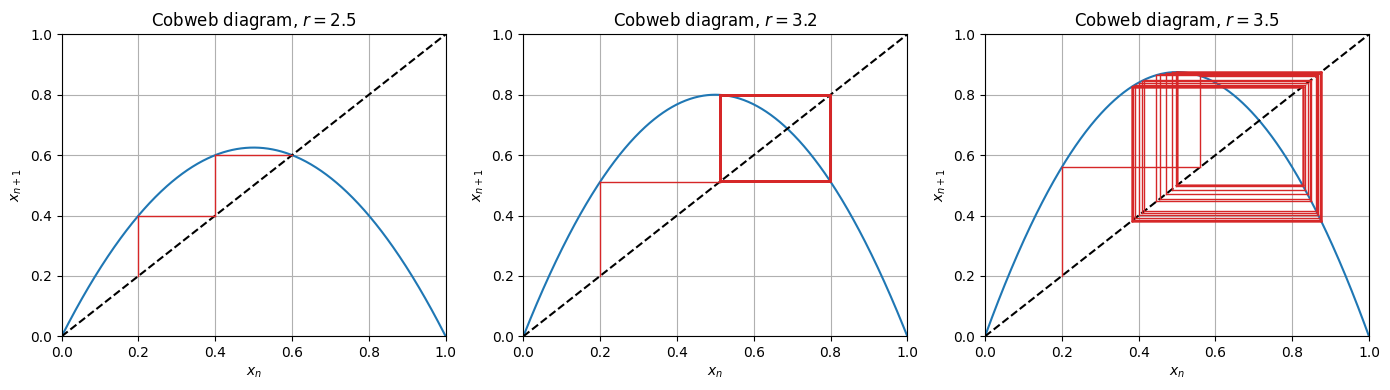

In [6]:
# Compare cobweb diagrams in three regimes.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, r in zip(axes, [2.5, 3.2, 3.5]):
    plot_cobweb(r, x0=0.2, n_steps=40, ax=ax)

plt.tight_layout()
plt.show()

## 8. Period Doubling as a Route to Chaos

The transition uncovered by May is not abrupt randomness appearing from nowhere. The structure first grows through a sequence of doubling periods:

$$
1 \to 2 \to 4 \to 8 \to 16 \to \cdots
$$

The intervals in $r$ where each stable period appears become shorter and shorter, accumulating at a finite parameter value near

$$
r_\infty \approx 3.56994567.
$$

Numerically, we can estimate the visible period by looking at the tail of a long orbit and checking whether the last values repeat.

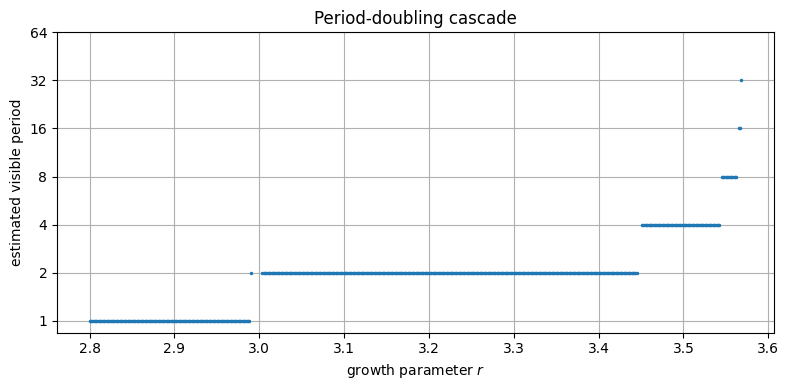

In [7]:
# Estimate visible low periods in the cascade before chaos becomes dominant.
r_scan = np.linspace(2.8, 3.57, 500)
periods = np.array([estimate_tail_period(r) for r in r_scan])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_scan, periods, linestyle="none", marker=".", ms=3)
ax.set_yscale("log", base=2)
ax.set_yticks([1, 2, 4, 8, 16, 32, 64])
ax.set_yticklabels(["1", "2", "4", "8", "16", "32", "64"])
ax.set_xlabel(r"growth parameter $r$")
ax.set_ylabel("estimated visible period")
ax.set_title("Period-doubling cascade")
plt.tight_layout()
plt.show()

This plot is only a numerical detector, not a proof. But it captures the main phenomenon May emphasized: the stable long-term behaviour becomes more and more intricate through repeated doubling before chaos takes over.

## 9. Bifurcation Diagram

The bifurcation diagram is the most famous visualization associated with May's work. For each parameter value $r$, we iterate the map for a long time, discard the transient part, and plot the remaining states.

If one asymptotic value remains, we see a stable fixed point. If two values remain, we see a period-2 orbit. When a whole vertical cloud appears, the asymptotic behaviour is chaotic.

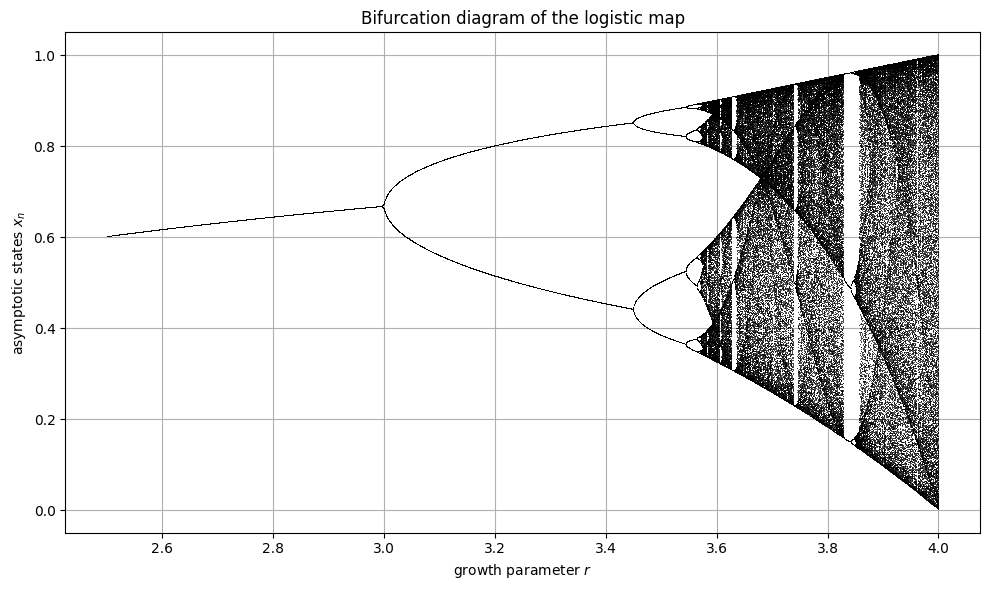

In [8]:
# Reproduce the classic bifurcation diagram.
r_values = np.linspace(2.5, 4.0, 3000)
rs, xs = bifurcation_data(r_values, x0=0.2, n_transient=800, n_keep=180)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rs, xs, ",", color="black", alpha=0.7)
ax.set_xlabel(r"growth parameter $r$")
ax.set_ylabel(r"asymptotic states $x_n$")
ax.set_title("Bifurcation diagram of the logistic map")
plt.tight_layout()
plt.show()

The branching structure shows the period-doubling cascade directly. Beyond the accumulation point, broad chaotic regions appear, but they are interrupted by narrow periodic windows. This mixture of order and disorder is part of what made the result so surprising.

## 10. Lyapunov Exponent

A good way to quantify the transition to chaos is to track how nearby trajectories stretch under iteration. For the logistic map, the local stretching factor is $|f'(x_n)|$, so the average exponential growth rate is

$$
\lambda = \lim_{N\to\infty} \frac{1}{N} \sum_{n=0}^{N-1} \log |r(1-2x_n)|.
$$

Interpretation:

- $\lambda < 0$: nearby trajectories contract, so the orbit settles to a stable structure.
- $\lambda = 0$: the system is at a bifurcation threshold.
- $\lambda > 0$: nearby trajectories separate exponentially, which is the signature of chaos.

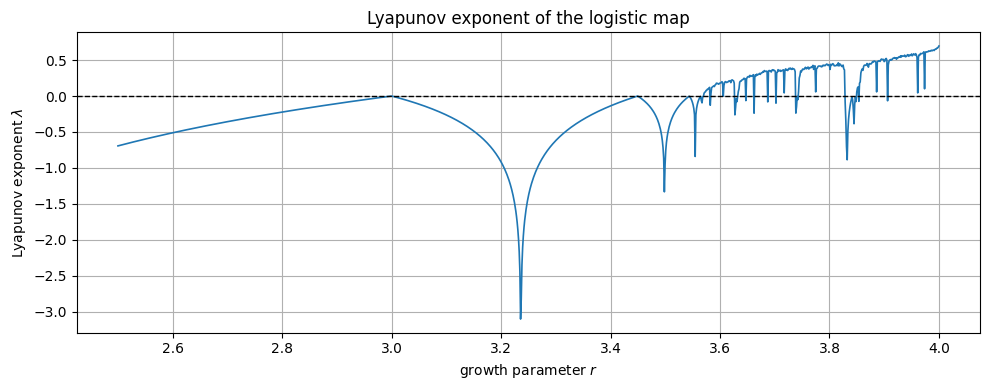

In [9]:
# Compute the Lyapunov exponent across the same parameter range.
r_values = np.linspace(2.5, 4.0, 1200)
lambdas = np.array([lyapunov_exponent(r) for r in r_values])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_values, lambdas, color="tab:blue", lw=1.2)
ax.axhline(0.0, color="black", linestyle="--", lw=1.0)
ax.set_xlabel(r"growth parameter $r$")
ax.set_ylabel(r"Lyapunov exponent $\lambda$")
ax.set_title("Lyapunov exponent of the logistic map")
plt.tight_layout()
plt.show()

The sign change in $\lambda$ closely tracks the onset of chaos. The narrow negative dips inside otherwise positive regions correspond to periodic windows inside the chaotic regime.

## 11. Sensitive Dependence on Initial Conditions

One of the clearest characteristics of chaos is that two almost identical initial states can evolve into noticeably different futures. The rule is deterministic, but long-term prediction becomes difficult because tiny uncertainties are amplified.

We can see this directly by starting two trajectories at nearly the same point.

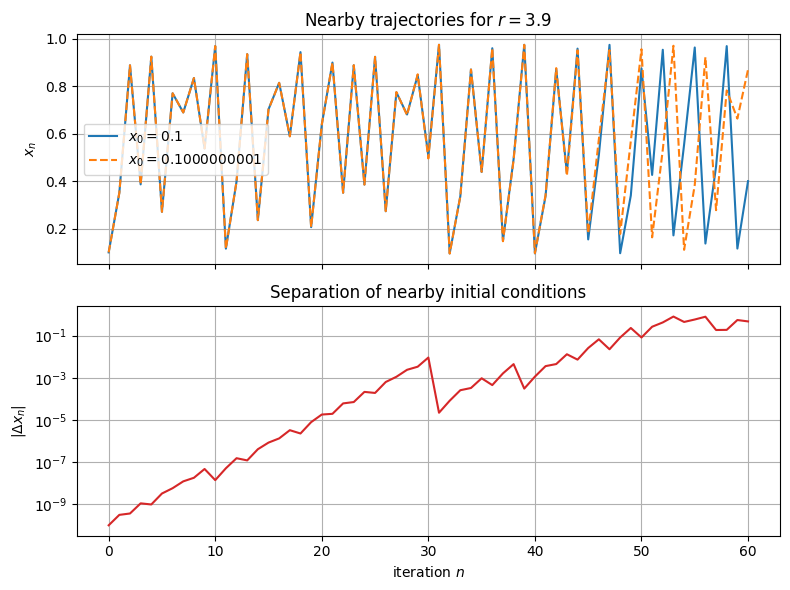

In [10]:
# Compare two nearby initial conditions in a chaotic regime.
r = 3.9
x0 = 0.1
x0_perturbed = x0 + 1e-10
n_iter = 60

orbit_a = simulate_logistic(r, x0, n_iter)
orbit_b = simulate_logistic(r, x0_perturbed, n_iter)
delta = np.abs(orbit_a - orbit_b)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(orbit_a, label=fr"$x_0={x0}$")
axes[0].plot(orbit_b, label=fr"$x_0={x0_perturbed}$", linestyle="--")
axes[0].set_ylabel(r"$x_n$")
axes[0].set_title(fr"Nearby trajectories for $r={r}$")
axes[0].legend(frameon=True)

axes[1].plot(np.maximum(delta, 1e-16), color="tab:red")
axes[1].set_yscale("log")
axes[1].set_xlabel("iteration $n$")
axes[1].set_ylabel(r"$|\Delta x_n|$")
axes[1].set_title("Separation of nearby initial conditions")

plt.tight_layout()
plt.show()

At first the two trajectories are visually indistinguishable. Then the difference grows until the two time series no longer track one another. This is the practical meaning of sensitive dependence on initial conditions.